# Homework 2 — Problem 1



In [1]:
# Cell 1: Imports and setup
import os
import time
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

OUT_DIR = Path('/content/homework2_problem1_outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda


In [2]:
# Cell 2: Provided Problem 1 sequence
TEXT = '''Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text.

At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model.

One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks.

Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time.

Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants.

In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology.
'''

print('Text length:', len(TEXT), 'characters')
print('First 300 characters:')
print(TEXT[:300])

Text length: 2392 characters
First 300 characters:
Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking


In [3]:
# Cell 3: Vocabulary and dataset preparation
class CharVocab:
    def __init__(self, text):
        self.chars = sorted(set(text))
        self.stoi = {ch: i for i, ch in enumerate(self.chars)}
        self.itos = {i: ch for ch, i in self.stoi.items()}
        self.size = len(self.chars)

    def encode(self, s):
        return [self.stoi[ch] for ch in s]

    def decode(self, ids):
        return ''.join(self.itos[int(i)] for i in ids)

class NextCharDataset(Dataset):
    def __init__(self, text, vocab, seq_len):
        self.vocab = vocab
        self.seq_len = seq_len
        encoded = torch.tensor(vocab.encode(text), dtype=torch.long)
        xs, ys = [], []
        for i in range(len(encoded) - seq_len):
            xs.append(encoded[i:i+seq_len])
            ys.append(encoded[i+seq_len])
        self.x = torch.stack(xs)
        self.y = torch.stack(ys)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

def make_loaders(text, seq_len, batch_size=32, val_fraction=0.20):
    vocab = CharVocab(text)
    dataset = NextCharDataset(text, vocab, seq_len)
    n_val = int(len(dataset) * val_fraction)
    n_train = len(dataset) - n_val

    # Keep the validation set as the final part of the sequence
    train_set, val_set = torch.utils.data.random_split(
        dataset,
        [n_train, n_val],
        generator=torch.Generator().manual_seed(SEED)
    )

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
    return vocab, train_loader, val_loader

vocab_test = CharVocab(TEXT)
print('Vocabulary size:', vocab_test.size)
print('Vocabulary characters:', vocab_test.chars)

Vocabulary size: 45
Vocabulary characters: ['\n', ' ', "'", '(', ')', ',', '-', '.', 'A', 'D', 'I', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [4]:
# Cell 4: RNN, LSTM, and GRU model
class CharRNNModel(nn.Module):
    def __init__(self, vocab_size, model_type='LSTM', embedding_dim=32, hidden_size=64,
                 num_layers=1, fc_hidden_size=0, dropout=0.0):
        super().__init__()
        model_type = model_type.upper()
        if model_type not in ['RNN', 'LSTM', 'GRU']:
            raise ValueError('model_type must be RNN, LSTM, or GRU')

        self.model_type = model_type
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.fc_hidden_size = fc_hidden_size
        self.dropout = dropout

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        recurrent_cls = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}[model_type]
        rnn_dropout = dropout if num_layers > 1 else 0.0
        self.recurrent = recurrent_cls(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=rnn_dropout
        )

        if fc_hidden_size > 0:
            self.fc = nn.Sequential(
                nn.Linear(hidden_size, fc_hidden_size),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(fc_hidden_size, vocab_size)
            )
        else:
            self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.recurrent(emb)
        last_hidden = out[:, -1, :]
        logits = self.fc(last_hidden)
        return logits

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def model_size_mb(model):
    return count_parameters(model) * 4 / (1024 ** 2)

def complexity_summary(model_type, seq_len, embedding_dim, hidden_size, num_layers, vocab_size):
    gates = {'RNN': 1, 'GRU': 3, 'LSTM': 4}[model_type]
    # Approx multiply-accumulate operations for one forward pass through one sequence
    # This is an estimate for comparison
    recurrent_macs_per_step = gates * (embedding_dim * hidden_size + hidden_size * hidden_size + hidden_size)
    output_macs = hidden_size * vocab_size
    approx_macs = seq_len * num_layers * recurrent_macs_per_step + output_macs
    return gates, int(approx_macs)

In [5]:
# Cell 5: Training, validation, and inference timing functions
def evaluate(model, data_loader, device):
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    total_loss, total_correct, total_count = 0.0, 0, 0
    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = loss_fn(logits, y)
            preds = logits.argmax(dim=1)
            total_loss += loss.item() * x.size(0)
            total_correct += (preds == y).sum().item()
            total_count += x.size(0)
    return total_loss / total_count, total_correct / total_count

def train_one_model(model, train_loader, val_loader, epochs=50, lr=0.003, grad_clip=1.0):
    model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []
    start = time.perf_counter()
    best_val_acc = 0.0

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, total_count = 0.0, 0
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            total_loss += loss.item() * x.size(0)
            total_count += x.size(0)

        train_loss = total_loss / total_count
        val_loss, val_acc = evaluate(model, val_loader, device)
        best_val_acc = max(best_val_acc, val_acc)
        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_accuracy': val_acc
        })

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(f'Epoch {epoch:03d}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}')

    training_time_sec = time.perf_counter() - start
    return history, best_val_acc, training_time_sec

def measure_inference_time(model, val_loader, batches=20):
    model.eval()
    times = []
    with torch.no_grad():
        for i, (x, _) in enumerate(val_loader):
            if i >= batches:
                break
            x = x.to(device)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            start = time.perf_counter()
            _ = model(x)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            times.append((time.perf_counter() - start) * 1000.0)
    return float(np.mean(times))

In [6]:
EPOCHS = 50
BATCH_SIZE = 32
EMBEDDING_DIM = 32
HIDDEN_SIZE = 64
NUM_LAYERS = 1
FC_HIDDEN_SIZE = 0
DROPOUT = 0.0
LR = 0.003

MODELS = ['RNN', 'LSTM', 'GRU']
SEQ_LENGTHS = [10, 20, 30]

summary_rows = []
history_rows = []
trained_models = {}

for seq_len in SEQ_LENGTHS:
    vocab, train_loader, val_loader = make_loaders(TEXT, seq_len, batch_size=BATCH_SIZE)

    for model_type in MODELS:
        print('\n' + '=' * 80)
        print(f'Training model={model_type}, sequence length={seq_len}')

        torch.manual_seed(SEED)
        model = CharRNNModel(
            vocab_size=vocab.size,
            model_type=model_type,
            embedding_dim=EMBEDDING_DIM,
            hidden_size=HIDDEN_SIZE,
            num_layers=NUM_LAYERS,
            fc_hidden_size=FC_HIDDEN_SIZE,
            dropout=DROPOUT
        )

        history, best_val_acc, training_time_sec = train_one_model(
            model, train_loader, val_loader, epochs=EPOCHS, lr=LR, grad_clip=1.0
        )
        final_val_loss, final_val_acc = evaluate(model, val_loader, device)
        inference_ms = measure_inference_time(model, val_loader)
        params = count_parameters(model)
        size_mb = model_size_mb(model)
        gates, approx_macs = complexity_summary(model_type, seq_len, EMBEDDING_DIM, HIDDEN_SIZE, NUM_LAYERS, vocab.size)

        key = f'{model_type}_seq{seq_len}'
        trained_models[key] = model.cpu()
        torch.save(model.state_dict(), OUT_DIR / f'{key}.pt')

        final_train_loss = history[-1]['train_loss']
        summary_rows.append({
            'model_type': model_type,
            'seq_len': seq_len,
            'vocab_size': vocab.size,
            'embedding_dim': EMBEDDING_DIM,
            'hidden_size': HIDDEN_SIZE,
            'num_layers': NUM_LAYERS,
            'fc_hidden_size': FC_HIDDEN_SIZE,
            'dropout': DROPOUT,
            'epochs': EPOCHS,
            'batch_size': BATCH_SIZE,
            'learning_rate': LR,
            'final_train_loss': final_train_loss,
            'final_val_loss': final_val_loss,
            'final_val_accuracy': final_val_acc,
            'best_val_accuracy': best_val_acc,
            'training_time_sec': training_time_sec,
            'inference_ms_per_batch': inference_ms,
            'trainable_parameters': params,
            'model_size_mb': size_mb,
            'gates_per_cell': gates,
            'approx_forward_macs_per_sequence': approx_macs,
            'complexity_note': f'O(seq_len * layers * gates * hidden_size^2), gates={gates}'
        })

        for row in history:
            history_rows.append({'model_type': model_type, 'seq_len': seq_len, **row})

summary_df = pd.DataFrame(summary_rows)
history_df = pd.DataFrame(history_rows)

summary_df.to_csv(OUT_DIR / 'problem1_results.csv', index=False)
history_df.to_csv(OUT_DIR / 'problem1_epoch_history.csv', index=False)

print('\nSaved results to:', OUT_DIR)
summary_df


Training model=RNN, sequence length=10
Epoch 001/50 | train_loss=3.0207 | val_loss=2.7422 | val_acc=0.2521
Epoch 010/50 | train_loss=1.4555 | val_loss=2.0302 | val_acc=0.4517
Epoch 020/50 | train_loss=0.8725 | val_loss=2.1302 | val_acc=0.4538
Epoch 030/50 | train_loss=0.5196 | val_loss=2.4037 | val_acc=0.4601
Epoch 040/50 | train_loss=0.3241 | val_loss=2.7409 | val_acc=0.4622
Epoch 050/50 | train_loss=0.2257 | val_loss=2.9974 | val_acc=0.4538

Training model=LSTM, sequence length=10
Epoch 001/50 | train_loss=3.1130 | val_loss=2.8051 | val_acc=0.2206
Epoch 010/50 | train_loss=1.3943 | val_loss=2.0134 | val_acc=0.4769
Epoch 020/50 | train_loss=0.6775 | val_loss=2.1127 | val_acc=0.4895
Epoch 030/50 | train_loss=0.2765 | val_loss=2.3543 | val_acc=0.5042
Epoch 040/50 | train_loss=0.1285 | val_loss=2.6161 | val_acc=0.5000
Epoch 050/50 | train_loss=0.0790 | val_loss=2.8149 | val_acc=0.4937

Training model=GRU, sequence length=10
Epoch 001/50 | train_loss=3.0581 | val_loss=2.7043 | val_acc=0.

,model_type,seq_len,vocab_size,embedding_dim,hidden_size,num_layers,fc_hidden_size,dropout,epochs,batch_size,...,final_val_loss,final_val_accuracy,best_val_accuracy,training_time_sec,inference_ms_per_batch,trainable_parameters,model_size_mb,gates_per_cell,approx_forward_macs_per_sequence,complexity_note
0,RNN,10,45,32,64,1,0,0.0,50,32,...,2.997423,0.453782,0.481092,9.131555,0.384799,10637,0.040577,1,64960,"O(seq_len * layers * gates * hidden_size^2), g..."
1,LSTM,10,45,32,64,1,0,0.0,50,32,...,2.814885,0.493697,0.516807,9.524603,0.405287,29453,0.112354,4,251200,"O(seq_len * layers * gates * hidden_size^2), g..."
2,GRU,10,45,32,64,1,0,0.0,50,32,...,3.137265,0.476891,0.510504,8.956776,0.348841,23181,0.088428,3,189120,"O(seq_len * layers * gates * hidden_size^2), g..."
3,RNN,20,45,32,64,1,0,0.0,50,32,...,2.687398,0.462025,0.487342,8.219437,0.442256,10637,0.040577,1,127040,"O(seq_len * layers * gates * hidden_size^2), g..."
4,LSTM,20,45,32,64,1,0,0.0,50,32,...,2.679769,0.464135,0.502110,8.857474,0.373378,29453,0.112354,4,499520,"O(seq_len * layers * gates * hidden_size^2), g..."
5,GRU,20,45,32,64,1,0,0.0,50,32,...,3.277203,0.489451,0.527426,8.875611,0.376213,23181,0.088428,3,375360,"O(seq_len * layers * gates * hidden_size^2), g..."
6,RNN,30,45,32,64,1,0,0.0,50,32,...,3.129667,0.451271,0.470339,10.083951,0.382602,10637,0.040577,1,189120,"O(seq_len * layers * gates * hidden_size^2), g..."
7,LSTM,30,45,32,64,1,0,0.0,50,32,...,2.793392,0.491525,0.504237,8.789881,0.485231,29453,0.112354,4,747840,"O(seq_len * layers * gates * hidden_size^2), g..."
8,GRU,30,45,32,64,1,0,0.0,50,32,...,3.240305,0.470339,0.502119,8.901961,0.353814,23181,0.088428,3,561600,"O(seq_len * layers * gates * hidden_size^2), g..."


In [7]:
# Cell 7: Display clean comparison table
cols = [
    'model_type', 'seq_len', 'final_train_loss', 'final_val_loss',
    'best_val_accuracy', 'training_time_sec', 'inference_ms_per_batch',
    'trainable_parameters', 'model_size_mb', 'approx_forward_macs_per_sequence'
]
comparison = summary_df[cols].sort_values(['seq_len', 'model_type']).reset_index(drop=True)
comparison

,model_type,seq_len,final_train_loss,final_val_loss,best_val_accuracy,training_time_sec,inference_ms_per_batch,trainable_parameters,model_size_mb,approx_forward_macs_per_sequence
0,GRU,10,0.064782,3.137265,0.510504,8.956776,0.348841,23181,0.088428,189120
1,LSTM,10,0.079017,2.814885,0.516807,9.524603,0.405287,29453,0.112354,251200
2,RNN,10,0.225674,2.997423,0.481092,9.131555,0.384799,10637,0.040577,64960
3,GRU,20,0.077780,3.277203,0.527426,8.875611,0.376213,23181,0.088428,375360
4,LSTM,20,0.067529,2.679769,0.502110,8.857474,0.373378,29453,0.112354,499520
5,RNN,20,0.265686,2.687398,0.487342,8.219437,0.442256,10637,0.040577,127040
6,GRU,30,0.065453,3.240305,0.502119,8.901961,0.353814,23181,0.088428,561600
7,LSTM,30,0.147861,2.793392,0.504237,8.789881,0.485231,29453,0.112354,747840
8,RNN,30,0.255348,3.129667,0.470339,10.083951,0.382602,10637,0.040577,189120


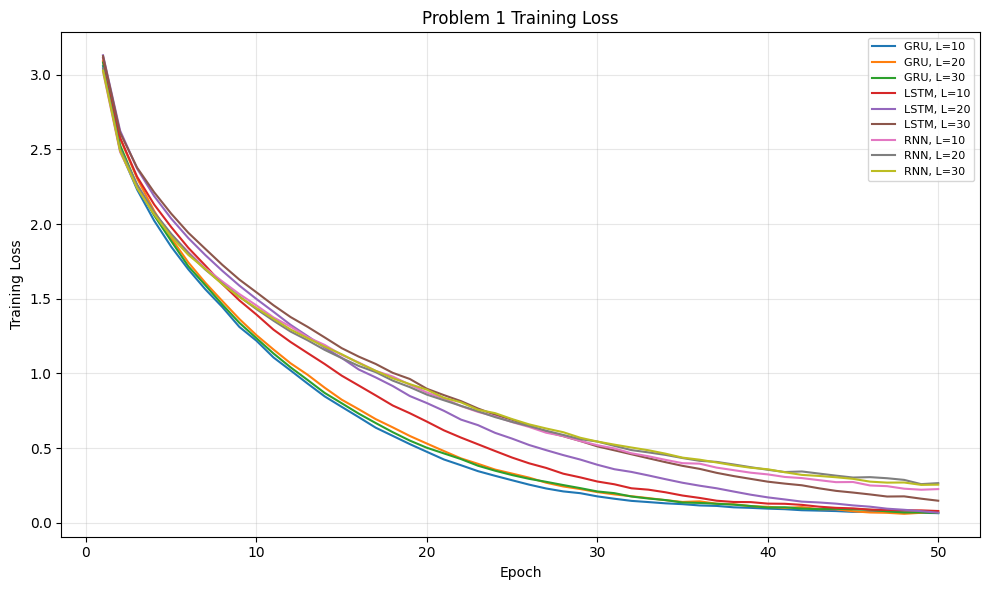

In [8]:
# Cell 8: Plot training loss curves
plt.figure(figsize=(10, 6))
for (model_type, seq_len), group in history_df.groupby(['model_type', 'seq_len']):
    plt.plot(group['epoch'], group['train_loss'], label=f'{model_type}, L={seq_len}')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Problem 1 Training Loss')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'problem1_loss_curves.png', dpi=200)
plt.show()

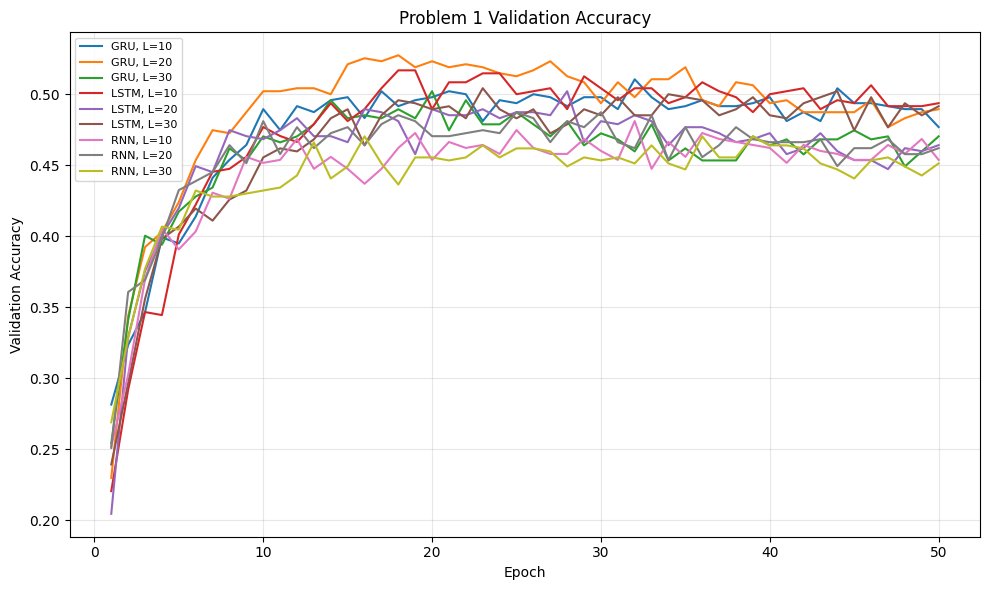

In [9]:
# Cell 9: Plot validation accuracy curves
plt.figure(figsize=(10, 6))
for (model_type, seq_len), group in history_df.groupby(['model_type', 'seq_len']):
    plt.plot(group['epoch'], group['val_accuracy'], label=f'{model_type}, L={seq_len}')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Problem 1 Validation Accuracy')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'problem1_accuracy_curves.png', dpi=200)
plt.show()

In [10]:
# Cell 10: Optional next-character generation sample for qualitative checking
def generate_text(model, vocab, start_text, length=200, seq_len=30, temperature=0.8):
    model = model.to(device)
    model.eval()
    generated = start_text

    with torch.no_grad():
        for _ in range(length):
            context = generated[-seq_len:]
            if len(context) < seq_len:
                context = ' ' * (seq_len - len(context)) + context
            x = torch.tensor([vocab.encode(context)], dtype=torch.long).to(device)
            logits = model(x)[0] / temperature
            probs = torch.softmax(logits, dim=0)
            next_id = torch.multinomial(probs, num_samples=1).item()
            generated += vocab.itos[next_id]
    return generated

# Example: use best model according to best validation accuracy
best_row = summary_df.sort_values('best_val_accuracy', ascending=False).iloc[0]
best_key = f"{best_row['model_type']}_seq{int(best_row['seq_len'])}"
print('Best model:', best_key)

vocab, _, _ = make_loaders(TEXT, int(best_row['seq_len']), batch_size=BATCH_SIZE)
print(generate_text(trained_models[best_key], vocab, start_text='Next character prediction ', length=300, seq_len=int(best_row['seq_len'])))

Best model: GRU_seq20
Next character prediction cont remememmollow. This task is and reaching the futar accural revicige the based on predicting the model.

One of the most popule text based it. This task is ess, ning allg the model adjusts its parametwor h hoft can enhance user experience in text and remememband the model.

One of the most popul
